# Patent — yearly F/E/G + Disruption trend

Mean **Disruption (CD)**, **F/E/G** (Foundation / Extension / Generalization) and the type-j fraction
by **grant year**, for each citation window (3 / 5 / 10 / all).
Aggregated from the per-patent disruption output.

## Raw / input data
```
/project/jevans/Dawoon/Science of Science/PatentView/output/patent_disruption.parquet   # patent_id, CD/F/E/G/ni/nj/nk x (_3,_5,_10,_all)
/project/jevans/Dawoon/Science of Science/PatentView/output/patent_metadata.parquet     # patent_id, grant_year
```

## Output
`/project/jevans/Dawoon/Science of Science/PatentView/output/patent_feg_disruption_trend.parquet` — one row per year:
`grant_year, n, CD_w_mean, F_w_mean, E_w_mean, G_w_mean, njfrac_w_mean` for `w in (3,5,10,all)`.
Only years with a defined CD are aggregated (i.e. patents that received >= 1 citation).

In [1]:
import os, sys, gc, time
import numpy as np, pandas as pd
sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/PatentView')
import pv_common as pv
ROOT, D, OUT = pv.BASE, pv.GRANTED, pv.OUT
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
# inline, not Agg: the figures are meant to be visible in the notebook itself.
# nbclient honours this magic and stores each figure as a display_data output;
# run_notebook.py strips magics, and its sbatch sets MPLBACKEND=Agg instead.
import pyarrow.parquet as pq
# duckdb is not installed in env/Curvature and installing into a shared env is not this
# notebook's business; the join below is pyarrow's instead.
DISR   = pv.out('patent_disruption.parquet')
META   = pv.out('patent_metadata.parquet')
OUT_FP = pv.out('patent_feg_disruption_trend.parquet')

ROOT: C:\Users\jdwoo\OneDrive\Desktop\Research\Science of Science


## 1. Aggregate mean CD / F / E / G by year (DuckDB, out-of-core)

In [2]:
# The duckdb query this cell used to run, in pandas. duckdb is not installed in
# env/Curvature and installing into a shared env is not this notebook's business.
# Semantics are matched deliberately:
#   avg() skips NULL          -> DataFrame.mean() skips NaN
#   nj/nullif(ni+nj+nk, 0)    -> NaN where the denominator is 0, so those rows drop out
#                                of the mean rather than counting as 0
WIN = ['_3', '_5', '_10', '_all']
MET = ['CD', 'F', 'E', 'G', 'ni', 'nj', 'nk']

meta = pd.read_parquet(META, columns=['patent_id', 'grant_year'])
disr = pd.read_parquet(DISR)
d = disr.merge(meta, on='patent_id', how='inner')
del disr, meta; gc.collect()

d = d[d['CD_all'].notna() & d['grant_year'].notna()]
d['grant_year'] = d['grant_year'].astype(int)

for w in WIN:
    den = d[f'ni{w}'] + d[f'nj{w}'] + d[f'nk{w}']
    d[f'njfrac{w}'] = np.where(den > 0, d[f'nj{w}'] / den, np.nan)

cols = [f'{m}{w}' for w in WIN for m in MET + ['njfrac']]
g  = d.groupby('grant_year')
tr = g[cols].mean()
tr.insert(0, 'n', g.size())
tr = tr.reset_index().rename(columns={'grant_year': 'year'})
tr = tr.rename(columns={c: f'{c}_mean' for c in cols})
del d, g; gc.collect()

tr = tr[(tr['year'] >= 1800) & (tr['year'] <= 2024)]
tr.to_parquet(OUT_FP, index=False)
print(f'WROTE {OUT_FP}  ({len(tr):,} years, {len(tr.columns)} cols)')
display(tr.tail(10))


WROTE C:\Users\jdwoo\OneDrive\Desktop\Research\Science of Science\notebook\patent\output\patent_feg_disruption_trend.parquet  (49 years, 34 cols)


,year,n,CD_3_mean,F_3_mean,E_3_mean,G_3_mean,ni_3_mean,nj_3_mean,nk_3_mean,njfrac_3_mean,...,nk_10_mean,njfrac_10_mean,CD_all_mean,F_all_mean,E_all_mean,G_all_mean,ni_all_mean,nj_all_mean,nk_all_mean,njfrac_all_mean
39,2015,203557,0.072053,0.032213,0.422327,0.545460,1.059279,1.268376,264.716604,0.018514,...,586.381888,0.024510,0.141711,0.108454,0.312581,0.578965,5.563400,5.992051,586.381888,0.024510
40,2016,197182,0.086639,0.032813,0.417971,0.549216,1.136251,1.424448,257.203023,0.020006,...,517.433021,0.025274,0.157473,0.099710,0.315411,0.584879,5.040308,5.443230,517.433021,0.025274
41,2017,200424,0.099738,0.032194,0.404895,0.562911,1.239989,1.670914,259.348041,0.022426,...,472.006371,0.026735,0.165565,0.089735,0.320706,0.589558,4.477089,5.056720,472.006371,0.026735
42,2018,177651,0.105183,0.032043,0.410868,0.557090,1.229160,1.928928,251.406798,0.024637,...,417.238107,0.028667,0.170290,0.079570,0.331745,0.588685,3.723773,4.587799,417.238107,0.028667
43,2019,187561,0.115574,0.030476,0.407917,0.561607,1.258373,2.113331,266.679090,0.025497,...,402.621542,0.029285,0.175332,0.067622,0.342619,0.589759,3.149114,4.344853,402.621542,0.029285
44,2020,166669,0.127909,0.033667,0.410809,0.555524,1.353639,2.061817,255.791466,0.030037,...,344.279626,0.033294,0.179804,0.056465,0.358459,0.585077,2.643185,3.405480,344.279626,0.033294
45,2021,135272,0.145746,0.033656,0.412971,0.553373,1.370693,2.279356,248.314600,0.036234,...,289.189056,0.038183,0.181099,0.043284,0.379946,0.576770,2.006114,2.885534,289.189056,0.038183
46,2022,107925,0.192048,0.031757,0.403770,0.564474,1.507880,2.009812,241.393264,0.043684,...,241.393264,0.043684,0.192048,0.031757,0.403770,0.564474,1.507880,2.009812,241.393264,0.043684
47,2023,77994,0.160411,0.017480,0.459754,0.522766,1.071031,1.481217,210.402390,0.055141,...,210.402390,0.055141,0.160411,0.017480,0.459754,0.522766,1.071031,1.481217,210.402390,0.055141
48,2024,42453,0.179005,0.007134,0.459459,0.533407,0.867289,1.016724,136.632252,0.060989,...,136.632252,0.060989,0.179005,0.007134,0.459459,0.533407,0.867289,1.016724,136.632252,0.060989


CPU times: total: 3.78 s
Wall time: 548 ms


## 2. Plot the yearly trends (inline)

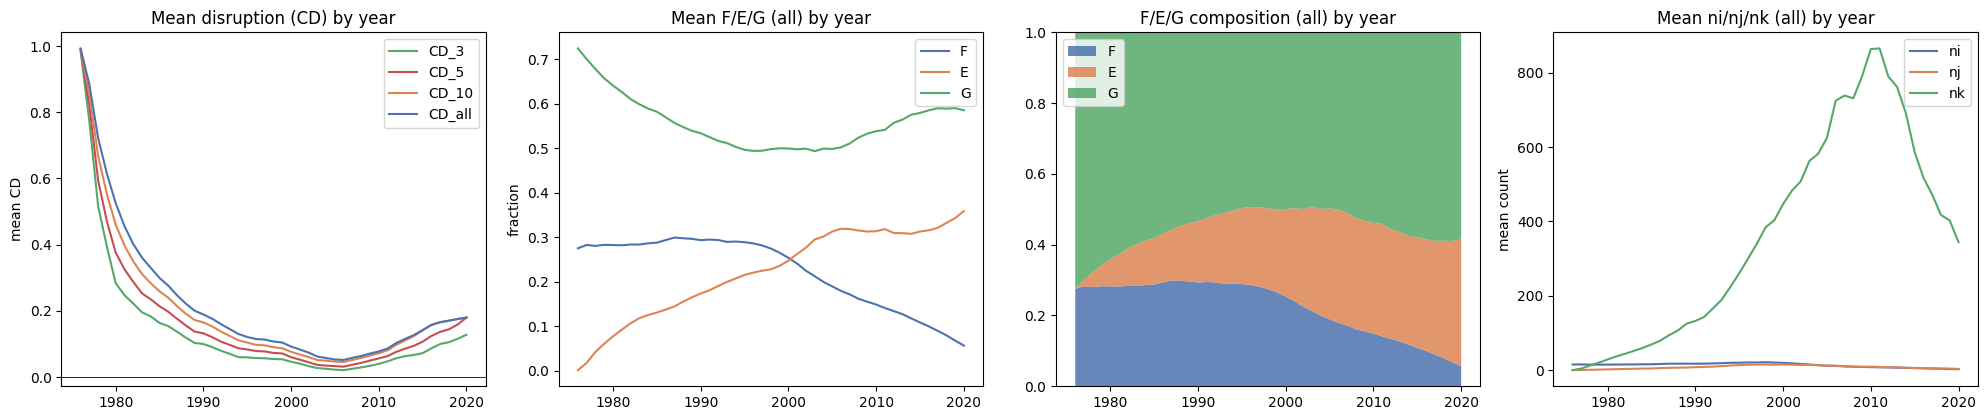

In [3]:
d = tr[(tr['year'] >= 1950) & (tr['year'] <= 2020)]
fig, ax = plt.subplots(1, 4, figsize=(20, 4.3))
for w, col in zip(['_3', '_5', '_10', '_all'], ['#55a868', '#c44e52', '#dd8452', '#4c72b0']):
    ax[0].plot(d['year'], d[f'CD{w}_mean'], label=f'CD{w}', color=col)
ax[0].axhline(0, color='k', lw=0.6); ax[0].set_title('Mean disruption (CD) by year'); ax[0].set_ylabel('mean CD'); ax[0].legend()
for m, col in zip(['F', 'E', 'G'], ['#4c72b0', '#dd8452', '#55a868']):
    ax[1].plot(d['year'], d[f'{m}_all_mean'], label=m, color=col)
ax[1].set_title('Mean F/E/G (all) by year'); ax[1].set_ylabel('fraction'); ax[1].legend()
ax[2].stackplot(d['year'], d['F_all_mean'], d['E_all_mean'], d['G_all_mean'],
                labels=['F', 'E', 'G'], colors=['#4c72b0', '#dd8452', '#55a868'], alpha=0.85)
ax[2].set_title('F/E/G composition (all) by year'); ax[2].set_ylim(0, 1); ax[2].legend(loc='upper left')
for nm, col in zip(['ni', 'nj', 'nk'], ['#4c72b0', '#dd8452', '#55a868']):
    ax[3].plot(d['year'], d[f'{nm}_all_mean'], label=nm, color=col)
ax[3].set_title('Mean ni/nj/nk (all) by year'); ax[3].set_ylabel('mean count'); ax[3].legend()
plt.tight_layout(); plt.show()